In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r"C:\Users\palan\Downloads\credit_card_fraud.xlsx")

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
print(df.head())

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [4]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(10000, 10)


In [5]:
print("Data Types:")
print(df.dtypes)

Data Types:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category          str
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB
None


In [7]:
print(df.describe())

       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000.50000    175.949849         11.593300             0.097800   
std        2886.89568    175.392827          6.922708             0.297059   
min           1.00000      0.000000          0.000000             0.000000   
25%        2500.75000     50.905000          6.000000             0.000000   
50%        5000.50000    122.095000         12.000000             0.000000   
75%        7500.25000    242.480000         18.000000             0.000000   
max       10000.00000   1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053           1.432559   
min             0.000000     

In [8]:
high_amount = df[df["amount"] > 500]

print(high_amount)

      transaction_id  amount  transaction_hour merchant_category  \
1                  2  541.82                 3            Travel   
11                12  630.64                18          Clothing   
33                34  535.26                 6          Clothing   
34                35  606.71                 7            Travel   
50                51  628.71                 4          Clothing   
...              ...     ...               ...               ...   
9940            9941  502.22                13       Electronics   
9971            9972  671.94                16            Travel   
9972            9973  566.35                 0       Electronics   
9978            9979  541.45                 5           Grocery   
9997            9998  527.75                21       Electronics   

      foreign_transaction  location_mismatch  device_trust_score  \
1                       1                  0                  87   
11                      0                  0   

In [9]:
sorted_df = df.sort_values(
    by="amount",
    ascending=False
)

print(sorted_df.head())

      transaction_id   amount  transaction_hour merchant_category  \
531              532  1471.04                15       Electronics   
3649            3650  1390.24                 1          Clothing   
9927            9928  1370.04                 7           Grocery   
6123            6124  1354.54                23       Electronics   
1464            1465  1339.51                 3           Grocery   

      foreign_transaction  location_mismatch  device_trust_score  \
531                     1                  0                  44   
3649                    0                  0                  43   
9927                    0                  0                  54   
6123                    0                  0                  38   
1464                    0                  0                  89   

      velocity_last_24h  cardholder_age  is_fraud  
531                   3              48         0  
3649                  1              61         0  
9927                

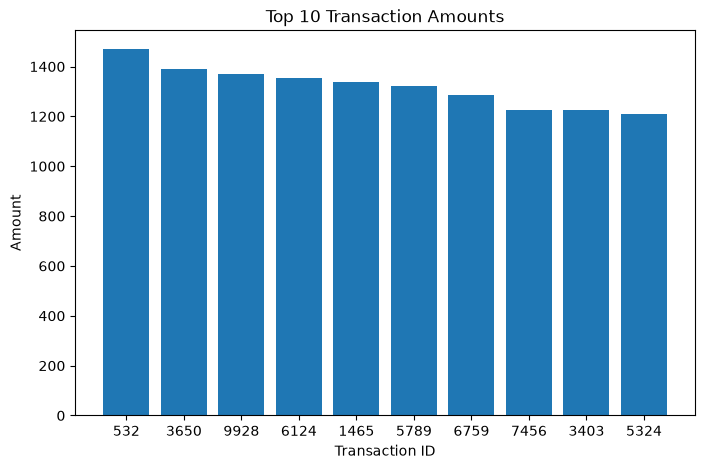

In [10]:
top10 = sorted_df.head(10)

plt.figure(figsize=(8,5))
plt.bar(top10["transaction_id"].astype(str), top10["amount"])

plt.title("Top 10 Transaction Amounts")
plt.xlabel("Transaction ID")
plt.ylabel("Amount")

plt.show()

In [11]:
print("Mean =", df["amount"].mean())

print("Median =", df["amount"].median())

print("Mode =")
print(df["amount"].mode())

print("Standard Deviation =", df["amount"].std())

Mean = 175.94984899999997
Median = 122.095
Mode =
0      0.04
1      3.48
2      6.12
3      7.41
4      9.10
5      9.55
6     14.42
7     97.72
8    150.14
Name: amount, dtype: float64
Standard Deviation = 175.39282728616223


In [12]:
dept_avg = df.groupby("merchant_category")["amount"].mean()

print(dept_avg)

merchant_category
Clothing       176.015478
Electronics    178.606058
Food           173.832226
Grocery        176.724594
Travel         174.785854
Name: amount, dtype: float64


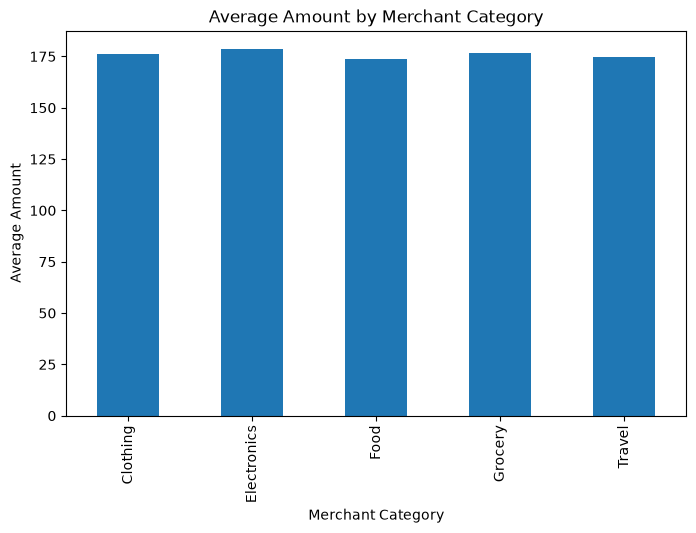

In [13]:
dept_avg.plot(kind="bar", figsize=(8,5))

plt.title("Average Amount by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Average Amount")

plt.show()

In [14]:
corr = df.select_dtypes(include=["number"]).corr()

print(corr)

                     transaction_id    amount  transaction_hour  \
transaction_id             1.000000 -0.017676         -0.020081   
amount                    -0.017676  1.000000         -0.007369   
transaction_hour          -0.020081 -0.007369          1.000000   
foreign_transaction       -0.003746  0.004094         -0.000255   
location_mismatch          0.003599  0.004232          0.004776   
device_trust_score         0.012292  0.009698          0.004054   
velocity_last_24h         -0.013903 -0.001133         -0.003709   
cardholder_age             0.005412  0.012735          0.012198   
is_fraud                  -0.010155  0.028404         -0.138665   

                     foreign_transaction  location_mismatch  \
transaction_id                 -0.003746           0.003599   
amount                          0.004094           0.004232   
transaction_hour               -0.000255           0.004776   
foreign_transaction             1.000000           0.001426   
location_misma

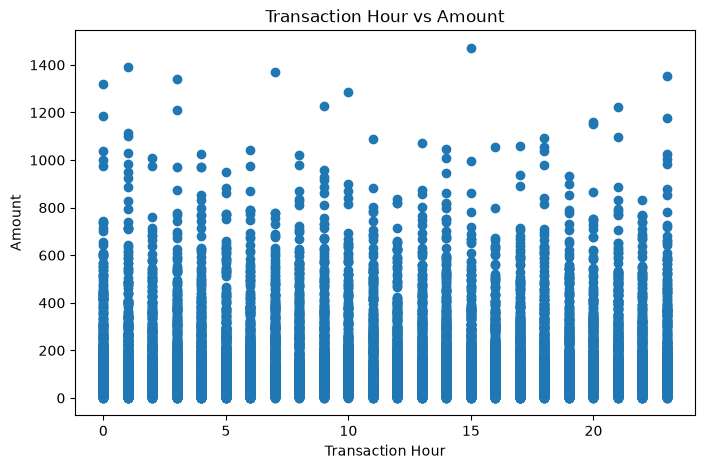

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(df["transaction_hour"], df["amount"])

plt.xlabel("Transaction Hour")
plt.ylabel("Amount")

plt.title("Transaction Hour vs Amount")

plt.show()